In [1]:
!pip install mediapipe==0.10.33 -q
print("✅ MediaPipe installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00
✅ MediaPipe installed!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys

project_path = "/content/drive/MyDrive/CV_PROJECT"
sys.path.insert(0, project_path)

print("✅ Path set to:", project_path)

# Let's confirm the files are there
import os
print("📁 Files found:", os.listdir(project_path))

Mounted at /content/drive
✅ Path set to: /content/drive/MyDrive/CV_PROJECT
📁 Files found: ['speech.ipynb', 'model', '__pycache__', 'data_set', 'collected_data.gsheet', 'data', 'ui_overlay.py', '6_UI.ipynb', 'model_loader.py', '4_model_training.ipynb', '5_prediction_logic.ipynb', 'config.py', '1_main.ipynb', 'utils.py', '2_MediaPipe.ipynb', '3_Landmark_Extraction.ipynb']


In [3]:
import os
project_path = "/content/drive/MyDrive/CV_PROJECT"

config_code = '''# config.py
import os

# FIXED: using correct folder name CV_PROJECT
BASE_DIR = "/content/drive/MyDrive/CV_PROJECT"
MODEL_PATH = os.path.join(BASE_DIR, "model", "isl_model.pkl")
MEDIAPIPE_MODEL_PATH = os.path.join(BASE_DIR, "model", "hand_landmarker.task")

FRAME_WIDTH = 640
FRAME_HEIGHT = 480

BUFFER_SIZE = 10
MAX_HANDS = 2
DETECTION_CONFIDENCE = 0.7
TRACKING_CONFIDENCE = 0.7
'''

with open(os.path.join(project_path, "config.py"), "w") as f:
    f.write(config_code)

print("✅ config.py updated with correct folder!")

✅ config.py updated with correct folder!


In [4]:
'''import os
project_path = "/content/drive/MyDrive/CV_PROJECT"

# Read existing utils.py and append the new function
with open(os.path.join(project_path, "utils.py"), "a") as f:
    f.write('''

def extract_landmarks(results):
    """
    Extracts landmarks from up to 2 hands with CONSISTENT ORDER:
    [Left hand, Right hand]

    Returns 126 features:
    - Left hand (63)
    - Right hand (63)

    If a hand is missing → filled with zeros
    """

    if not hand_detected(results):
        return None

    # Prepare placeholders
    left_hand  = [0.0] * LANDMARKS_PER_HAND
    right_hand = [0.0] * LANDMARKS_PER_HAND

    # Loop through detected hands WITH handedness
    for hand, handedness in zip(results.hand_landmarks, results.handedness):

        label = handedness[0].category_name  # "Left" or "Right"

        features = []
        for lm in hand:
            features.extend([lm.x, lm.y, lm.z])

        if label == "Left":
            left_hand = features
        elif label == "Right":
            right_hand = features

    # Final consistent order: LEFT + RIGHT
    return left_hand + right_hand

def normalize_landmarks(landmarks):
    """
    Optional but useful: makes landmarks relative to the wrist position.
    This means the model works even if the hand moves around the screen.
    The wrist is landmark 0 — we subtract its position from all others.
    """
    if landmarks is None:
        return None

    # Wrist position is the first 3 values (x, y, z of landmark 0)
    wrist_x = landmarks[0]
    wrist_y = landmarks[1]
    wrist_z = landmarks[2]

    normalized = []
    for i in range(0, len(landmarks), 3):
        normalized.append(landmarks[i]   - wrist_x)
        normalized.append(landmarks[i+1] - wrist_y)
        normalized.append(landmarks[i+2] - wrist_z)

    return normalized
''')

print("✅ utils.py updated with landmark extraction!")'''

✅ utils.py updated with landmark extraction!


📸 Show your hand to the camera...


<IPython.core.display.Javascript object>

✅ Raw landmarks extracted!    Total values: 126
✅ Normalized landmarks ready! Total values: 126

📊 First 9 values (landmark 0, 1, 2):
   Wrist  → x=0.000, y=0.000, z=0.000
   Thumb1 → x=0.000, y=0.000, z=0.000
   Thumb2 → x=0.000, y=0.000, z=0.000


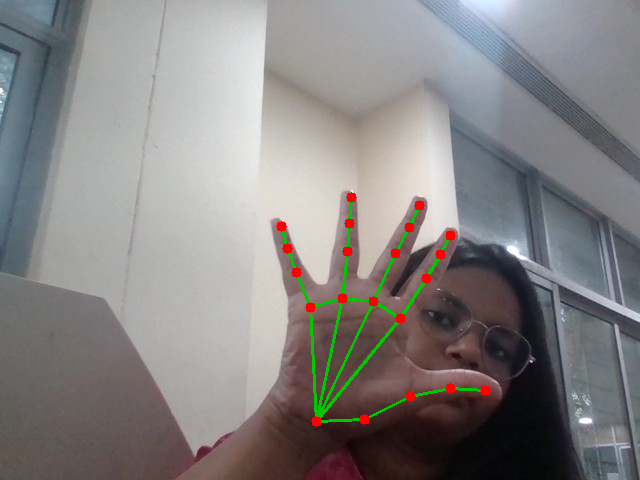

In [7]:
import importlib
import utils
importlib.reload(utils)  # reload so new functions are available

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io
import config


def capture_frame_from_colab():
    js_code = Javascript('''
        async function captureFrame() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);
            const stream = await navigator.mediaDevices.getUserMedia({video: {width:640, height:480}});
            video.srcObject = stream;
            await new Promise(resolve => {
                video.onloadedmetadata = () => video.play().then(resolve);
            });
            await new Promise(resolve => setTimeout(resolve, 1500));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth || 640;
            canvas.height = video.videoHeight || 480;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureFrame()
            .then(r => element.textContent = r)
            .catch(e => element.textContent = 'ERROR:' + e.message);
    ''')
    display(js_code)
    result = eval_js('captureFrame()', timeout_sec=15)
    image_bytes = b64decode(result.split(',')[1])
    frame = np.array(Image.open(io.BytesIO(image_bytes)))
    return cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)


def show_frame(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))


# --- Run ---
model_path = "/content/drive/MyDrive/CV_PROJECT/model/hand_landmarker.task"

detector = utils.init_mediapipe(
    model_path=model_path,
    max_hands=config.MAX_HANDS,
    detection_conf=config.DETECTION_CONFIDENCE,
    tracking_conf=config.TRACKING_CONFIDENCE
)

print("📸 Show your hand to the camera...")
frame = capture_frame_from_colab()
frame = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))

results, annotated_frame = utils.detect_hand(frame, detector)

# Extract landmarks
landmarks = utils.extract_landmarks(results)
normalized = utils.normalize_landmarks(landmarks)
if landmarks is not None and len(landmarks) != 126:
    print("⚠️ Feature size error")

if landmarks:
    print(f"✅ Raw landmarks extracted!    Total values: {len(landmarks)}")
    print(f"✅ Normalized landmarks ready! Total values: {len(normalized)}")
    print(f"\n📊 First 9 values (landmark 0, 1, 2):")
    print(f"   Wrist  → x={landmarks[0]:.3f}, y={landmarks[1]:.3f}, z={landmarks[2]:.3f}")
    print(f"   Thumb1 → x={landmarks[3]:.3f}, y={landmarks[4]:.3f}, z={landmarks[5]:.3f}")
    print(f"   Thumb2 → x={landmarks[6]:.3f}, y={landmarks[7]:.3f}, z={landmarks[8]:.3f}")
else:
    print("⚠️ No hand detected — try again with hand clearly visible")

show_frame(annotated_frame)


In [ ]:
# things done in this notebook
# 63 landmark values extracted
# normalized landmarks working
# extract_landmarks() in utils.py
# normalize_landmarks() in utils.py
# data ready for ML model